In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/ADNI-DIAN_Comparison_Study_Data_Subset_05_23_22_14Jun2026 (2) (1).csv'
df = pd.read_csv(file_path)
display(df.head())

,COLPROT,RID,VISCODE,VISCODE2,EXAMDATE,VISITAGE,CDRGLOB,CSFDATE,EDUC,MRI_SCANDATE,...,PET_SCANDATE,ORIGIN,DIAN_ID,DIAN_APOE,DIAN_GROUP,DIAN_CDRSB_BL,DIAN_YEARS_BL,DIAN_MMSE,NEYO,update_stamp
0,ADNI2,42,v21,m84,2013-01-23,80.003290,1.0,2013-01-24,18,2013-01-23,...,2013-01-23,ADNI,213,33.0,2,0.5,7.203290,24.0,6.729637,2022-05-25 15:48:02
1,ADNI1,42,nv,m48,2010-03-18,77.150440,1.0,NaN,18,NaN,...,NaN,ADNI,213,33.0,2,0.5,4.350440,23.0,3.876797,2022-05-25 15:48:02
2,ADNI2,42,v06,m60,2011-04-13,78.220940,1.0,2011-04-14,18,NaN,...,2011-04-13,ADNI,213,33.0,2,0.5,5.420940,23.0,4.947296,2022-05-25 15:48:02
3,ADNI1,42,nv,m06,2006-05-02,73.273648,0.5,NaN,18,NaN,...,NaN,ADNI,213,33.0,2,0.5,0.473648,28.0,0.000000,2022-05-25 15:48:02
4,ADNI1,42,nv,m18,2007-05-10,74.294870,0.5,NaN,18,NaN,...,NaN,ADNI,213,33.0,2,0.5,1.494870,21.0,1.021218,2022-05-25 15:48:03


In [ ]:
print(df.columns.tolist())

['COLPROT', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'VISITAGE', 'CDRGLOB', 'CSFDATE', 'EDUC', 'MRI_SCANDATE', 'FLUF', 'WORDIM', 'LOGIMEM', 'DIGIF', 'DIGIFLEN', 'DIGIB', 'DIGIBLEN', 'ANIMALS', 'VEG', 'TRAILA', 'TRAILARR', 'TRAILB', 'TRAILBRR', 'WAIS', 'MEMUNITS', 'BOSTON', 'WORDDEL', 'MR_TOTV_WMHYPOINTENSITIES', 'MR_TOTV_INTRACRANIAL', 'MR_TOTV_HIPPOCAMPUS', 'FDG_FSUVR_RSF_TOT_CTX_PRECUNEUS', 'FDG_FSUVR_RSF_TOT_HIPPOCAMPUS', 'FDG_FSUVR_RSF_TOT_CORTMEAN', 'PIB_FSUVR_RSF_TOT_CTX_PRECUNEUS', 'PIB_FSUVR_RSF_TOT_HIPPOCAMPUS', 'PIB_FSUVR_RSF_TOT_CORTMEAN', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO', 'ABRUPT', 'STEPWISE', 'SOMATIC', 'EMOT', 'HXHYPER', 'HXSTROKE', 'FOCLSYM', 'FOCLSIGN', 'HACHIN', 'CDRSUM', 'GDS', 'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE', 'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL', 'DECSUB', 'VASC', 'ALCDEM', 'FTD', 'PPAPH', 'PSP', 'CORT', 'HUNT', 'PRION', 'DEP', 'PARK', 'HYCEPH', 'COGOT

In [ ]:
print(df["ADGROUP"].value_counts(dropna=False))

ADGROUP
1.0    2711
0.0     438
NaN     103
Name: count, dtype: int64


In [ ]:
df["TARGET"] = (df["ADGROUP"] == 1.0).astype(int)
print(df['TARGET'].value_counts())

TARGET
1    2711
0     541
Name: count, dtype: int64


In [ ]:
features = [
    "VISITAGE","EDUC","BIRTHMO","BIRTHYR",
    "HISPANIC","RACE","PRIMLANG","MARISTAT",
    "HANDED","GENDER",

    "MOMDEM","MOMAUTO","DADDEM","DADAUTO",

    "WORDIM","WORDDEL","LOGIMEM","MEMUNITS",
    "DIGIF","DIGIFLEN","DIGIB","DIGIBLEN",
    "ANIMALS","VEG","BOSTON",
    "TRAILA","TRAILARR","TRAILB","TRAILBRR",
    "WAIS","FLUF",

    "ABRUPT","STEPWISE","SOMATIC","EMOT",
    "HXHYPER","HXSTROKE","FOCLSYM","FOCLSIGN",
    "HACHIN","GDS",

    "BILLS","TAXES","SHOPPING","GAMES",
    "STOVE","MEALPREP","EVENTS","PAYATTN",
    "REMDATES","TRAVEL"
]

In [ ]:
X = df[features]
y = df["TARGET"]

In [ ]:
cat_cols = X.select_dtypes(include=["object"]).columns

for col in cat_cols:
    X[col] = X[col].astype("category")

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2168, number of negative: 433
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001664 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1142
[LightGBM] [Info] Number of data points in the train set: 2601, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.833526 -> initscore=1.610823
[LightGBM] [Info] Start training from score 1.610823


LGBMClassifier(learning_rate=0.05, n_estimators=500, random_state=42)

In [ ]:
alz_prob = model.predict_proba(X_test)[:,1]

print(alz_prob[:10])

[9.98408045e-01 9.99819037e-01 9.99982080e-01 9.99992275e-01
 3.99649349e-04 2.99928368e-01 9.99969696e-01 9.97515440e-01
 9.99966139e-01 9.99933937e-01]


In [ ]:
print(y.value_counts())

print(y_train.value_counts())
print(y_test.value_counts())

TARGET
1    2711
0     541
Name: count, dtype: int64
TARGET
1    2168
0     433
Name: count, dtype: int64
TARGET
1    543
0    108
Name: count, dtype: int64


In [ ]:
print(X_train.shape)
print(X_train.isnull().sum().sum())

(2601, 51)
37469


In [ ]:
print(X_train.dtypes)

VISITAGE    float64
EDUC          int64
BIRTHMO     float64
BIRTHYR     float64
HISPANIC      int64
RACE          int64
PRIMLANG      int64
MARISTAT    float64
HANDED        int64
GENDER        int64
MOMDEM      float64
MOMAUTO     float64
DADDEM      float64
DADAUTO     float64
WORDIM      float64
WORDDEL     float64
LOGIMEM     float64
MEMUNITS    float64
DIGIF       float64
DIGIFLEN    float64
DIGIB       float64
DIGIBLEN    float64
ANIMALS     float64
VEG         float64
BOSTON      float64
TRAILA      float64
TRAILARR    float64
TRAILB      float64
TRAILBRR    float64
WAIS        float64
FLUF        float64
ABRUPT      float64
STEPWISE    float64
SOMATIC     float64
EMOT        float64
HXHYPER     float64
HXSTROKE    float64
FOCLSYM     float64
FOCLSIGN    float64
HACHIN      float64
GDS         float64
BILLS       float64
TAXES       float64
SHOPPING    float64
GAMES       float64
STOVE       float64
MEALPREP    float64
EVENTS      float64
PAYATTN     float64
REMDATES    float64


In [ ]:
for col in X_train.columns:
    pct = X_train[col].isna().mean()*100
    if pct > 50:
        print(col, round(pct,2), "% missing")

DADAUTO 56.32 % missing
DIGIF 72.51 % missing
DIGIFLEN 72.55 % missing
DIGIB 72.78 % missing
DIGIBLEN 72.82 % missing
VEG 72.47 % missing
WAIS 72.86 % missing
ABRUPT 82.58 % missing
STEPWISE 82.58 % missing
SOMATIC 82.58 % missing
EMOT 82.58 % missing
HXHYPER 82.58 % missing
HXSTROKE 82.58 % missing
FOCLSYM 82.58 % missing
FOCLSIGN 82.58 % missing
HACHIN 82.58 % missing


In [ ]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [ ]:
for col in X_train.select_dtypes(include="object").columns:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [ ]:
drop_cols = [
    "DIGIF","DIGIFLEN","DIGIB","DIGIBLEN",
    "VEG","WAIS",
    "ABRUPT","STEPWISE","SOMATIC","EMOT",
    "HXHYPER","HXSTROKE","FOCLSYM",
    "FOCLSIGN","HACHIN"
]

X = X.drop(columns=drop_cols)

In [ ]:
print(y_train.value_counts())
print(y_train.dtype)
print(set(y_train))

TARGET
1    2168
0     433
Name: count, dtype: int64
int64
{0, 1}


In [ ]:
model = LGBMClassifier(
    n_estimators=20,
    objective="binary",
    random_state=42
)

model.fit(X_train, y_train)

print(model.classes_)

[LightGBM] [Info] Number of positive: 2168, number of negative: 433
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1142
[LightGBM] [Info] Number of data points in the train set: 2601, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.833526 -> initscore=1.610823
[LightGBM] [Info] Start training from score 1.610823
[0 1]


In [ ]:
pred = model.predict_proba(X_test)[:,1]

print(pred[:20])
print(pred.min(), pred.max())

[0.83091202 0.92165351 0.96169436 0.96664671 0.17092867 0.73863743
 0.91812534 0.89342754 0.9629626  0.96790478 0.91859369 0.96337962
 0.40906973 0.11789106 0.9621664  0.9683756  0.96828634 0.96664671
 0.94312863 0.96790478]
0.11789105524375795 0.9700975992430331


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

pred_prob = model.predict_proba(X_test)[:,1]
pred_class = model.predict(X_test)

print("AUC:", roc_auc_score(y_test, pred_prob))
print("Accuracy:", accuracy_score(y_test, pred_class))

AUC: 0.9098799536184435
Accuracy: 0.9001536098310292


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

     Feature  Importance
3    BIRTHYR          57
0   VISITAGE          45
17  MEMUNITS          34
2    BIRTHMO          33
1       EDUC          30
30      FLUF          29
16   LOGIMEM          27
22   ANIMALS          25
40       GDS          24
27    TRAILB          23
14    WORDIM          21
24    BOSTON          21
49  REMDATES          21
25    TRAILA          21
11   MOMAUTO          17
50    TRAVEL          16
15   WORDDEL          15
42     TAXES          14
23       VEG          13
13   DADAUTO          12


In [ ]:
model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

In [ ]:
print(df["ADGROUP"].value_counts())
print(df["COHORT"].value_counts())
print(df["ORIGIN"].value_counts())

ADGROUP
1.0    2711
0.0     438
Name: count, dtype: int64
COHORT
0    3252
Name: count, dtype: int64
ORIGIN
ADNI    3252
Name: count, dtype: int64


In [ ]:
print(df[["ADGROUP","CDRGLOB"]].groupby("ADGROUP").describe())

        CDRGLOB                                             
          count      mean       std  min  25%  50%  75%  max
ADGROUP                                                     
0.0       435.0  0.143678  0.229054  0.0  0.0  0.0  0.5  1.0
1.0      2666.0  0.690360  0.406856  0.0  0.5  0.5  1.0  3.0


In [ ]:
pd.crosstab(df["ADGROUP"], df["CDRGLOB"])

CDRGLOB,0.0,0.5,1.0,2.0,3.0
ADGROUP,,,,,
0.0,311,123,1,0,0
1.0,39,1875,620,113,19


In [ ]:
missing = X.isnull().mean() * 100

missing_df = pd.DataFrame({
    "Feature": missing.index,
    "Missing_%": missing.values
}).sort_values("Missing_%", ascending=False)

print(missing_df)

     Feature  Missing_%
13   DADAUTO  56.549815
11   MOMAUTO  42.681427
24      FLUF  31.334563
17  MEMUNITS  24.569496
16   LOGIMEM  23.954490
25       GDS  10.854859
22    TRAILB  10.116851
23  TRAILBRR  10.116851
21  TRAILARR   5.442804
20    TRAILA   5.412054
15   WORDDEL   5.319803
14    WORDIM   5.196802
19    BOSTON   4.920049
18   ANIMALS   4.366544
12    DADDEM   2.275523
26     BILLS   1.629766
27     TAXES   1.629766
28  SHOPPING   1.568266
33   PAYATTN   1.568266
29     GAMES   1.568266
31  MEALPREP   1.537515
32    EVENTS   1.537515
35    TRAVEL   1.537515
30     STOVE   1.537515
34  REMDATES   1.506765
10    MOMDEM   0.953260
2    BIRTHMO   0.861009
3    BIRTHYR   0.861009
7   MARISTAT   0.861009
1       EDUC   0.000000
0   VISITAGE   0.000000
6   PRIMLANG   0.000000
8     HANDED   0.000000
5       RACE   0.000000
9     GENDER   0.000000
4   HISPANIC   0.000000


In [ ]:
drop_cols = [
    "DADAUTO",   # 56.5%
]

In [ ]:
drop_cols.append("MOMAUTO")

In [ ]:
print(df["ADGROUP"].value_counts())

ADGROUP
1.0    2711
0.0     438
Name: count, dtype: int64


In [ ]:
df = df.dropna(subset=["ADGROUP"]).copy()

df["TARGET"] = df["ADGROUP"].astype(int)

print(df["TARGET"].value_counts())

TARGET
1    2711
0     438
Name: count, dtype: int64


In [ ]:
features = [

    # Demographics
    "VISITAGE",
    "EDUC",
    "HISPANIC",
    "RACE",
    "PRIMLANG",
    "MARISTAT",
    "HANDED",
    "GENDER",

    # Family History
    "MOMDEM",
    "DADDEM",

    # Memory
    "WORDIM",
    "WORDDEL",
    "LOGIMEM",
    "MEMUNITS",

    # Language
    "ANIMALS",
    "BOSTON",
    "FLUF",

    # Executive Function
    "TRAILA",
    "TRAILARR",
    "TRAILB",
    "TRAILBRR",

    # Mood
    "GDS",

    # Functional Assessment
    "BILLS",
    "TAXES",
    "SHOPPING",
    "GAMES",
    "STOVE",
    "MEALPREP",
    "EVENTS",
    "PAYATTN",
    "REMDATES",
    "TRAVEL"
]

In [ ]:
X = df[features].copy()
y = df["TARGET"].copy()

In [ ]:
missing = X.isnull().mean()*100

print(
    missing.sort_values(ascending=False)
)

FLUF        29.977771
MEMUNITS    22.959670
LOGIMEM     22.356304
GDS         10.003176
TRAILB       7.875516
TRAILBRR     7.875516
TRAILARR     3.175611
TRAILA       3.143855
WORDDEL      3.080343
WORDIM       2.921562
BOSTON       2.667513
DADDEM       2.222928
ANIMALS      2.127660
BILLS        1.302001
TAXES        1.302001
SHOPPING     1.238488
PAYATTN      1.238488
GAMES        1.238488
MEALPREP     1.206732
STOVE        1.206732
TRAVEL       1.206732
EVENTS       1.206732
REMDATES     1.174976
MOMDEM       0.857415
MARISTAT     0.762147
RACE         0.000000
HISPANIC     0.000000
VISITAGE     0.000000
HANDED       0.000000
PRIMLANG     0.000000
GENDER       0.000000
EDUC         0.000000
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

TARGET
1    2169
0     350
Name: count, dtype: int64
TARGET
1    542
0     88
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Fit the model before making predictions
model.fit(X_train, y_train)

pred_class = model.predict(X_test)
pred_prob = model.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, pred_prob))
print("Accuracy:", accuracy_score(y_test, pred_class))
print("F1:", f1_score(y_test, pred_class))
print("Precision:", precision_score(y_test, pred_class))
print("Recall:", recall_score(y_test, pred_class))

[LightGBM] [Info] Number of positive: 2169, number of negative: 350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 917
[LightGBM] [Info] Number of data points in the train set: 2519, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
AUC: 0.9382967125125796
Accuracy: 0.9126984126984127
F1: 0.9494020239190433
Precision: 0.9467889908256881
Recall: 0.9520295202952029


In [ ]:
features_no_age = [f for f in features if f != "VISITAGE"]

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2169, number of negative: 350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000546 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 917
[LightGBM] [Info] Number of data points in the train set: 2519, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=500,
               objective='binary', random_state=42)

In [ ]:
pred_prob = model.predict_proba(X_test)[:,1]

print(pred_prob[:10])

[0.99763935 0.9999734  0.99990244 0.00165241 0.99999992 0.00392514
 0.99999928 0.14364738 0.99999895 0.99971755]


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

     Feature  Importance
0   VISITAGE        1745
16      FLUF        1333
19    TRAILB        1298
17    TRAILA        1145
13  MEMUNITS        1079
14   ANIMALS         964
1       EDUC         880
10    WORDIM         754
11   WORDDEL         752
12   LOGIMEM         724
15    BOSTON         532
21       GDS         518
5   MARISTAT         316
9     DADDEM         289
23     TAXES         245
8     MOMDEM         239
30  REMDATES         211
27  MEALPREP         204
20  TRAILBRR         204
22     BILLS         191
24  SHOPPING         176
31    TRAVEL         172
3       RACE         155
29   PAYATTN         154
7     GENDER         138
25     GAMES         136
4   PRIMLANG         114
6     HANDED         110
28    EVENTS          82
26     STOVE          67
2   HISPANIC          45
18  TRAILARR          28


In [ ]:
import joblib

joblib.dump(model, "alzheimers_lightgbm.pkl")

['alzheimers_lightgbm.pkl']

In [ ]:
import os
print(os.path.exists("alzheimers_lightgbm.pkl"))

True


In [ ]:
from google.colab import files

files.download("alzheimers_lightgbm.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_class)
print(cm)

[[ 59  29]
 [ 26 516]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_class))

              precision    recall  f1-score   support

           0       0.69      0.67      0.68        88
           1       0.95      0.95      0.95       542

    accuracy                           0.91       630
   macro avg       0.82      0.81      0.82       630
weighted avg       0.91      0.91      0.91       630



In [ ]:
features_no_age = [
    f for f in features
    if f != "VISITAGE"
]

In [ ]:
X = df[features_no_age].copy()
y = df["TARGET"].copy()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from lightgbm import LGBMClassifier

model_no_age = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

model_no_age.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2169, number of negative: 350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 662
[LightGBM] [Info] Number of data points in the train set: 2519, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=500,
               objective='binary', random_state=42)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

pred_prob = model_no_age.predict_proba(X_test)[:,1]
pred_class = model_no_age.predict(X_test)

print("AUC:", roc_auc_score(y_test, pred_prob))
print("Accuracy:", accuracy_score(y_test, pred_class))
print("F1:", f1_score(y_test, pred_class))
print("Precision:", precision_score(y_test, pred_class))
print("Recall:", recall_score(y_test, pred_class))

AUC: 0.9254444817175445
Accuracy: 0.9031746031746032
F1: 0.943778801843318
Precision: 0.9429097605893186
Recall: 0.9446494464944649


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_no_age.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

     Feature  Importance
18    TRAILB        1670
15      FLUF        1480
16    TRAILA        1178
12  MEMUNITS        1169
0       EDUC        1118
13   ANIMALS        1115
10   WORDDEL         880
9     WORDIM         872
11   LOGIMEM         855
14    BOSTON         660
20       GDS         583
7     MOMDEM         310
4   MARISTAT         303
19  TRAILBRR         287
21     BILLS         251


In [ ]:
import joblib

joblib.dump(model_no_age,
            "alzheimers_clinical_no_age.pkl")

['alzheimers_clinical_no_age.pkl']

AUC = 0.9254444817175445


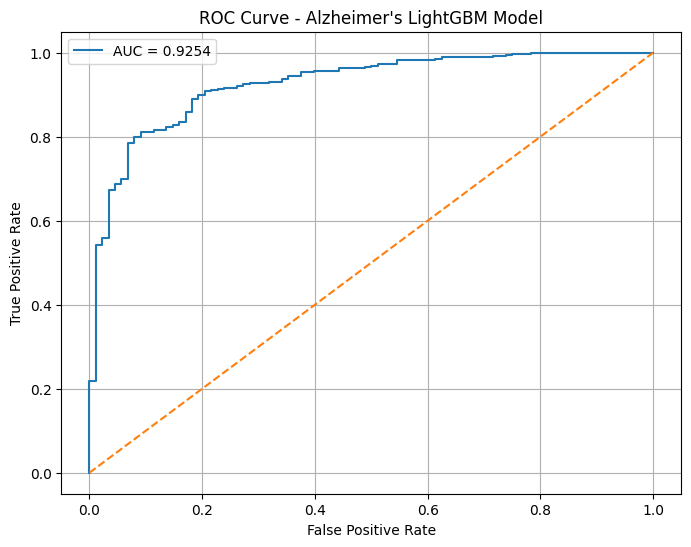

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities
pred_prob = model_no_age.predict_proba(X_test)[:,1]

# ROC points
fpr, tpr, thresholds = roc_curve(y_test, pred_prob)

# AUC
auc_score = roc_auc_score(y_test, pred_prob)

print("AUC =", auc_score)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Alzheimer's LightGBM Model")
plt.legend()
plt.grid(True)

plt.show()

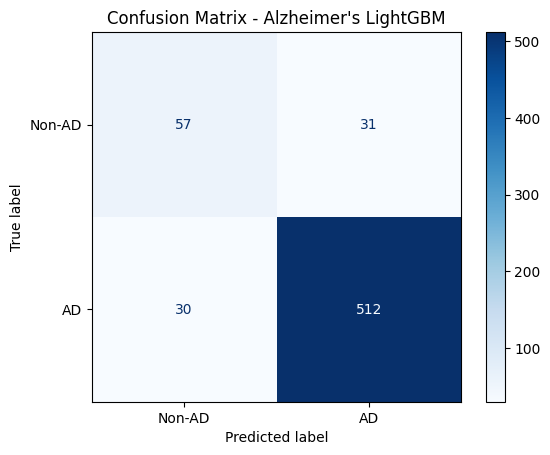

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-AD", "AD"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Alzheimer's LightGBM")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, pred_class)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-AD", "Actual AD"],
    columns=["Predicted Non-AD", "Predicted AD"]
)

print(cm_df)

               Predicted Non-AD  Predicted AD
Actual Non-AD                57            31
Actual AD                    30           512


In [ ]:
print(X_train.columns.tolist())

['EDUC', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'DADDEM', 'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS', 'ANIMALS', 'BOSTON', 'FLUF', 'TRAILA', 'TRAILARR', 'TRAILB', 'TRAILBRR', 'GDS', 'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE', 'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL']


## Training a new model with updated features and XGBoost

In [ ]:
new_features = [
    "EDUC", "BIRTHMO", "BIRTHYR", "HISPANIC", "RACE", "PRIMLANG",
    "MARISTAT", "HANDED", "GENDER", "MOMDEM", "MOMAUTO", "DADDEM",
    "DADAUTO", "WORDIM", "WORDDEL", "LOGIMEM", "MEMUNITS", "DIGIF",
    "DIGIFLEN", "DIGIB", "DIGIBLEN", "ANIMALS", "VEG", "BOSTON",
    "TRAILA", "TRAILB", "WAIS", "FLUF", "HXHYPER", "HXSTROKE",
    "HACHIN", "GDS", "VISITAGE"
]

# Filter df to include only rows where 'ADGROUP' is not NaN before creating X and y
df_filtered = df.dropna(subset=["ADGROUP"]).copy()

X_new = df_filtered[new_features].copy()
y_new = df_filtered["ADGROUP"].astype(int).copy()

print(f"Shape of X_new: {X_new.shape}")
print(f"Shape of y_new: {y_new.shape}")

Shape of X_new: (3149, 33)
Shape of y_new: (3149,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    stratify=y_new,
    random_state=42
)

print("New X_train shape:", X_train_new.shape)
print("New y_train value counts:\n", y_train_new.value_counts())
print("New X_test shape:", X_test_new.shape)
print("New y_test value counts:\n", y_test_new.value_counts())

New X_train shape: (2519, 33)
New y_train value counts:
 ADGROUP
1    2169
0     350
Name: count, dtype: int64
New X_test shape: (630, 33)
New y_test value counts:
 ADGROUP
1    542
0     88
Name: count, dtype: int64


In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb

# Convert categorical columns to 'category' dtype for XGBoost if any
for col in X_train_new.select_dtypes(include='object').columns:
    X_train_new[col] = X_train_new[col].astype('category')
    X_test_new[col] = X_test_new[col].astype('category')

# Handle missing values using imputation or other methods if needed
# For simplicity, we'll fill NaN with 0 for now as XGBoost can handle NaNs,
# but it's good practice to explicitly handle them if the model expects it.
# Note: XGBoost can handle NaNs by default, but filling them might be necessary for consistent feature types.
# Let's check for NaNs first
print(f"NaNs in X_train_new before fillna: {X_train_new.isnull().sum().sum()}")
print(f"NaNs in X_test_new before fillna: {X_test_new.isnull().sum().sum()}")

X_train_new_filled = X_train_new.fillna(0)
X_test_new_filled = X_test_new.fillna(0)

print(f"NaNs in X_train_new after fillna: {X_train_new_filled.isnull().sum().sum()}")
print(f"NaNs in X_test_new after fillna: {X_test_new_filled.isnull().sum().sum()}")

model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    learning_rate=0.05,
    use_label_encoder=False, # Deprecated in newer XGBoost versions
    random_state=42
)

model_xgb.fit(X_train_new_filled, y_train_new)

print(model_xgb)

NaNs in X_train_new before fillna: 22430
NaNs in X_test_new before fillna: 5626
NaNs in X_train_new after fillna: 0
NaNs in X_test_new after fillna: 0


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:04:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score

pred_prob_xgb = model_xgb.predict_proba(X_test_new_filled)[:, 1]
pred_class_xgb = model_xgb.predict(X_test_new_filled)

print("XGBoost Model Performance:")
print("AUC:", roc_auc_score(y_test_new, pred_prob_xgb))
print("Accuracy:", accuracy_score(y_test_new, pred_class_xgb))
print("F1:", f1_score(y_test_new, pred_class_xgb))
print("Precision:", precision_score(y_test_new, pred_class_xgb))
print("Recall:", recall_score(y_test_new, pred_class_xgb))

XGBoost Model Performance:
AUC: 0.9174563904729957
Accuracy: 0.9142857142857143
F1: 0.9509981851179673
Precision: 0.9357142857142857
Recall: 0.966789667896679


## 5-Fold Cross-Validation with XGBoost

In [ ]:
ge

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import xgboost as xgb

# Redefine features and target for clarity, even though they are already set in X_new, y_new
new_features_cv = [
    "EDUC", "BIRTHMO", "BIRTHYR", "HISPANIC", "RACE", "PRIMLANG",
    "MARISTAT", "HANDED", "GENDER", "MOMDEM", "MOMAUTO", "DADDEM",
    "DADAUTO", "WORDIM", "WORDDEL", "LOGIMEM", "MEMUNITS", "DIGIF",
    "DIGIFLEN", "DIGIB", "DIGIBLEN", "ANIMALS", "VEG", "BOSTON",
    "TRAILA", "TRAILB", "WAIS", "FLUF", "HXHYPER", "HXSTROKE",
    "HACHIN", "GDS", "VISITAGE"
]

# Ensure df_filtered is used from previous cells or re-create if needed
if 'df_filtered' not in locals():
    df_filtered = df.dropna(subset=["ADGROUP"]).copy()

X_cv = df_filtered[new_features_cv].copy()
y_cv = df_filtered["ADGROUP"].astype(int).copy()

# Fill NaNs with 0 as done before for consistency
X_cv_filled = X_cv.fillna(0)

# Initialize Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
aucs = []
accuracies = []
f1_scores = []
precisions = []
recalls = []

print("Starting 5-Fold Cross-Validation...")

for fold, (train_index, test_index) in enumerate(skf.split(X_cv_filled, y_cv)):
    print(f"\n--- Fold {fold+1} ---")

    X_train_fold, X_test_fold = X_cv_filled.iloc[train_index], X_cv_filled.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    # Initialize XGBoost model for the fold
    model_xgb_cv = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=500,
        learning_rate=0.05,
        use_label_encoder=False, # Deprecated in newer XGBoost versions
        random_state=42
    )

    # Train model
    model_xgb_cv.fit(X_train_fold, y_train_fold)

    # Predict probabilities and classes
    pred_prob_fold = model_xgb_cv.predict_proba(X_test_fold)[:, 1]
    pred_class_fold = model_xgb_cv.predict(X_test_fold)

    # Calculate metrics
    auc_fold = roc_auc_score(y_test_fold, pred_prob_fold)
    accuracy_fold = accuracy_score(y_test_fold, pred_class_fold)
    f1_fold = f1_score(y_test_fold, pred_class_fold)
    precision_fold = precision_score(y_test_fold, pred_class_fold)
    recall_fold = recall_score(y_test_fold, pred_class_fold)

    # Store metrics
    aucs.append(auc_fold)
    accuracies.append(accuracy_fold)
    f1_scores.append(f1_fold)
    precisions.append(precision_fold)
    recalls.append(recall_fold)

    # Print metrics for the current fold
    print(f"AUC: {auc_fold:.4f}")
    print(f"Accuracy: {accuracy_fold:.4f}")
    print(f"F1 Score: {f1_fold:.4f}")
    print(f"Precision: {precision_fold:.4f}")
    print(f"Recall: {recall_fold:.4f}")

print("\n--- Average Metrics Across 5 Folds ---")
print(f"Average AUC: {np.mean(aucs):.4f} (+/- {np.std(aucs):.4f})")
print(f"Average Accuracy: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
print(f"Average F1 Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
print(f"Average Precision: {np.mean(precisions):.4f} (+/- {np.std(precisions):.4f})")
print(f"Average Recall: {np.mean(recalls):.4f} (+/- {np.std(recalls):.4f})")

Starting 5-Fold Cross-Validation...

--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9196
Accuracy: 0.9175
F1 Score: 0.9532
Precision: 0.9315
Recall: 0.9761

--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9123
Accuracy: 0.9190
F1 Score: 0.9538
Precision: 0.9361
Recall: 0.9723

--- Fold 3 ---


...

AUC: 0.9144
Accuracy: 0.9206
F1 Score: 0.9549
Precision: 0.9346
Recall: 0.9760

--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9571
Accuracy: 0.9270
F1 Score: 0.9586
Precision: 0.9351
Recall: 0.9834

--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9472
Accuracy: 0.9237
F1 Score: 0.9566
Precision: 0.9379
Recall: 0.9760

--- Average Metrics Across 5 Folds ---
Average AUC: 0.9301 (+/- 0.0184)
Average Accuracy: 0.9216 (+/- 0.0034)
Average F1 Score: 0.9554 (+/- 0.0020)
Average Precision: 0.9350 (+/- 0.0021)
Average Recall: 0.9768 (+/- 0.0036)


## Missing Values Percentage for the 33 Attributes

In [ ]:
import pandas as pd

# Ensure X_cv is available. If not, re-create it from df_filtered
if 'X_cv' not in locals():
    if 'df_filtered' not in locals():
        df_filtered = df.dropna(subset=["ADGROUP"]).copy()
    new_features_cv = [
        "EDUC", "BIRTHMO", "BIRTHYR", "HISPANIC", "RACE", "PRIMLANG",
        "MARISTAT", "HANDED", "GENDER", "MOMDEM", "MOMAUTO", "DADDEM",
        "DADAUTO", "WORDIM", "WORDDEL", "LOGIMEM", "MEMUNITS", "DIGIF",
        "DIGIFLEN", "DIGIB", "DIGIBLEN", "ANIMALS", "VEG", "BOSTON",
        "TRAILA", "TRAILB", "WAIS", "FLUF", "HXHYPER", "HXSTROKE",
        "HACHIN", "GDS", "VISITAGE"
    ]
    X_cv = df_filtered[new_features_cv].copy()

missing_percentages = X_cv.isnull().mean() * 100

missing_df_all_features = pd.DataFrame({
    'Feature': missing_percentages.index,
    'Missing_%': missing_percentages.values
}).sort_values(by='Missing_%', ascending=False)

print(missing_df_all_features)


     Feature  Missing_%
30    HACHIN  81.867259
29  HXSTROKE  81.867259
28   HXHYPER  81.867259
26      WAIS  72.435694
20  DIGIBLEN  72.372182
19     DIGIB  72.340426
18  DIGIFLEN  72.149889
22       VEG  72.118133
17     DIGIF  72.118133
12   DADAUTO  56.621150
10   MOMAUTO  42.711972
27      FLUF  29.977771
16  MEMUNITS  22.959670
15   LOGIMEM  22.356304
31       GDS  10.003176
25    TRAILB   7.875516
24    TRAILA   3.143855
14   WORDDEL   3.080343
13    WORDIM   2.921562
23    BOSTON   2.667513
11    DADDEM   2.222928
21   ANIMALS   2.127660
9     MOMDEM   0.857415
6   MARISTAT   0.762147
2    BIRTHYR   0.762147
1    BIRTHMO   0.762147
0       EDUC   0.000000
4       RACE   0.000000
3   HISPANIC   0.000000
8     GENDER   0.000000
5   PRIMLANG   0.000000
7     HANDED   0.000000
32  VISITAGE   0.000000


In [ ]:
cols_to_drop = missing_df_all_features[missing_df_all_features['Missing_%'] > 50]['Feature'].tolist()
print(f"Columns to be dropped: {cols_to_drop}")

Columns to be dropped: ['HACHIN', 'HXSTROKE', 'HXHYPER', 'WAIS', 'DIGIBLEN', 'DIGIB', 'DIGIFLEN', 'VEG', 'DIGIF', 'DADAUTO']


In [ ]:
X_cv_reduced = X_cv.drop(columns=cols_to_drop)

print(f"Shape of X_cv after dropping columns: {X_cv_reduced.shape}")

missing_percentages_reduced = X_cv_reduced.isnull().mean() * 100

missing_df_reduced = pd.DataFrame({
    'Feature': missing_percentages_reduced.index,
    'Missing_%': missing_percentages_reduced.values
}).sort_values(by='Missing_%', ascending=False)

print("\nMissing percentages after dropping high-missing columns:")
print(missing_df_reduced.head(10))

Shape of X_cv after dropping columns: (3149, 23)

Missing percentages after dropping high-missing columns:
     Feature  Missing_%
10   MOMAUTO  42.711972
20      FLUF  29.977771
15  MEMUNITS  22.959670
14   LOGIMEM  22.356304
21       GDS  10.003176
19    TRAILB   7.875516
18    TRAILA   3.143855
13   WORDDEL   3.080343
12    WORDIM   2.921562
17    BOSTON   2.667513


In [ ]:
print(missing_df_reduced)

     Feature  Missing_%
10   MOMAUTO  42.711972
20      FLUF  29.977771
15  MEMUNITS  22.959670
14   LOGIMEM  22.356304
21       GDS  10.003176
19    TRAILB   7.875516
18    TRAILA   3.143855
13   WORDDEL   3.080343
12    WORDIM   2.921562
17    BOSTON   2.667513
11    DADDEM   2.222928
16   ANIMALS   2.127660
9     MOMDEM   0.857415
1    BIRTHMO   0.762147
2    BIRTHYR   0.762147
6   MARISTAT   0.762147
4       RACE   0.000000
3   HISPANIC   0.000000
0       EDUC   0.000000
5   PRIMLANG   0.000000
7     HANDED   0.000000
8     GENDER   0.000000
22  VISITAGE   0.000000


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import xgboost as xgb

# Extract features that still have missing values from missing_df_reduced
features_with_missing_values = missing_df_reduced[missing_df_reduced['Missing_%'] > 0]['Feature'].tolist()
print(f"Features selected for training (still have missing values): {features_with_missing_values}")

# Ensure df_filtered and y_cv are available from previous steps
if 'df_filtered' not in locals():
    # This part should ideally not be reached if previous cells ran correctly
    df_filtered = df.dropna(subset=["ADGROUP"]).copy()

# Prepare X and y for cross-validation with the selected features
X_selected = df_filtered[features_with_missing_values].copy()
y_cv_selected = df_filtered["ADGROUP"].astype(int).copy()

# Fill NaNs with 0 for these selected features
X_selected_filled = X_selected.fillna(0)

# Initialize Stratified K-Fold Cross-Validation
skf_selected = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
aucs_selected = []
accuracies_selected = []
f1_scores_selected = []
precisions_selected = []
recalls_selected = []

print("\nStarting 5-Fold Cross-Validation with Selected Features (those with initial missing values)...")

for fold, (train_index, test_index) in enumerate(skf_selected.split(X_selected_filled, y_cv_selected)):
    print(f"\n--- Fold {fold+1} ---")

    X_train_fold, X_test_fold = X_selected_filled.iloc[train_index], X_selected_filled.iloc[test_index]
    y_train_fold, y_test_fold = y_cv_selected.iloc[train_index], y_cv_selected.iloc[test_index]

    # Initialize XGBoost model for the fold
    model_xgb_cv_selected = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=500,
        learning_rate=0.05,
        use_label_encoder=False,
        random_state=42
    )

    # Train model
    model_xgb_cv_selected.fit(X_train_fold, y_train_fold)

    # Predict probabilities and classes
    pred_prob_fold = model_xgb_cv_selected.predict_proba(X_test_fold)[:, 1]
    pred_class_fold = model_xgb_cv_selected.predict(X_test_fold)

    # Calculate metrics
    auc_fold = roc_auc_score(y_test_fold, pred_prob_fold)
    accuracy_fold = accuracy_score(y_test_fold, pred_class_fold)
    f1_fold = f1_score(y_test_fold, pred_class_fold)
    precision_fold = precision_score(y_test_fold, pred_class_fold)
    recall_fold = recall_score(y_test_fold, pred_class_fold)

    # Store metrics
    aucs_selected.append(auc_fold)
    accuracies_selected.append(accuracy_fold)
    f1_scores_selected.append(f1_fold)
    precisions_selected.append(precision_fold)
    recalls_selected.append(recall_fold)

    # Print metrics for the current fold
    print(f"AUC: {auc_fold:.4f}")
    print(f"Accuracy: {accuracy_fold:.4f}")
    print(f"F1 Score: {f1_fold:.4f}")
    print(f"Precision: {precision_fold:.4f}")
    print(f"Recall: {recall_fold:.4f}")

print("\n--- Average Metrics Across 5 Folds (Selected Features) ---")
print(f"Average AUC: {np.mean(aucs_selected):.4f} (+/- {np.std(aucs_selected):.4f})")
print(f"Average Accuracy: {np.mean(accuracies_selected):.4f} (+/- {np.std(accuracies_selected):.4f})")
print(f"Average F1 Score: {np.mean(f1_scores_selected):.4f} (+/- {np.std(f1_scores_selected):.4f})")
print(f"Average Precision: {np.mean(precisions_selected):.4f} (+/- {np.std(precisions_selected):.4f})")
print(f"Average Recall: {np.mean(recalls_selected):.4f} (+/- {np.std(recalls_selected):.4f})")

Features selected for training (still have missing values): ['MOMAUTO', 'FLUF', 'MEMUNITS', 'LOGIMEM', 'GDS', 'TRAILB', 'TRAILA', 'WORDDEL', 'WORDIM', 'BOSTON', 'DADDEM', 'ANIMALS', 'MOMDEM', 'BIRTHMO', 'BIRTHYR', 'MARISTAT']

Starting 5-Fold Cross-Validation with Selected Features (those with initial missing values)...

--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:15:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9091
Accuracy: 0.9063
F1 Score: 0.9467
Precision: 0.9291
Recall: 0.9650

--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:15:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9027
Accuracy: 0.9032
F1 Score: 0.9452
Precision: 0.9212
Recall: 0.9705

--- Fold 3 ---


...

AUC: 0.9093
Accuracy: 0.9063
F1 Score: 0.9467
Precision: 0.9274
Recall: 0.9668

--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:15:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9447
Accuracy: 0.9270
F1 Score: 0.9586
Precision: 0.9351
Recall: 0.9834

--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:15:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9351
Accuracy: 0.9221
F1 Score: 0.9556
Precision: 0.9394
Recall: 0.9723

--- Average Metrics Across 5 Folds (Selected Features) ---
Average AUC: 0.9202 (+/- 0.0166)
Average Accuracy: 0.9130 (+/- 0.0096)
Average F1 Score: 0.9506 (+/- 0.0055)
Average Precision: 0.9304 (+/- 0.0063)
Average Recall: 0.9716 (+/- 0.0064)


## Training a new XGBoost model with 23 features from `missing_df_reduced`

The `missing_df_reduced` table, which you referenced, contains 23 features. I will use these features to train a new model. Similar to previous steps, missing values will be filled with 0 before training.

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np

# Features from the missing_df_reduced table (23 features)
features_for_new_training = missing_df_reduced['Feature'].tolist()

print(f"Features selected for training: {len(features_for_new_training)} attributes.\n{features_for_new_training}")

# Prepare X and y for training with these features
X_new_train_23 = df_filtered[features_for_new_training].copy()
y_new_train_23 = df_filtered["ADGROUP"].astype(int).copy()

# Fill NaNs with 0
X_new_train_23_filled = X_new_train_23.fillna(0)

# Initialize Stratified K-Fold Cross-Validation
skf_23_features = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
aucs_23 = []
accuracies_23 = []
f1_scores_23 = []
precisions_23 = []
recalls_23 = []

print("\nStarting 5-Fold Cross-Validation with 23 Selected Features...")

for fold, (train_index, test_index) in enumerate(skf_23_features.split(X_new_train_23_filled, y_new_train_23)):
    print(f"\n--- Fold {fold+1} ---")

    X_train_fold, X_test_fold = X_new_train_23_filled.iloc[train_index], X_new_train_23_filled.iloc[test_index]
    y_train_fold, y_test_fold = y_new_train_23.iloc[train_index], y_new_train_23.iloc[test_index]

    # Initialize XGBoost model for the fold
    model_xgb_cv_23 = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=500,
        learning_rate=0.05,
        use_label_encoder=False, # Deprecated in newer XGBoost versions
        random_state=42
    )

    # Train model
    model_xgb_cv_23.fit(X_train_fold, y_train_fold)

    # Predict probabilities and classes
    pred_prob_fold = model_xgb_cv_23.predict_proba(X_test_fold)[:, 1]
    pred_class_fold = model_xgb_cv_23.predict(X_test_fold)

    # Calculate metrics
    auc_fold = roc_auc_score(y_test_fold, pred_prob_fold)
    accuracy_fold = accuracy_score(y_test_fold, pred_class_fold)
    f1_fold = f1_score(y_test_fold, pred_class_fold)
    precision_fold = precision_score(y_test_fold, pred_class_fold)
    recall_fold = recall_score(y_test_fold, pred_class_fold)

    # Store metrics
    aucs_23.append(auc_fold)
    accuracies_23.append(accuracy_fold)
    f1_scores_23.append(f1_fold)
    precisions_23.append(precision_fold)
    recalls_23.append(recall_fold)

    # Print metrics for the current fold
    print(f"AUC: {auc_fold:.4f}")
    print(f"Accuracy: {accuracy_fold:.4f}")
    print(f"F1 Score: {f1_fold:.4f}")
    print(f"Precision: {precision_fold:.4f}")
    print(f"Recall: {recall_fold:.4f}")

print("\n--- Average Metrics Across 5 Folds (23 Features) ---")
print(f"Average AUC: {np.mean(aucs_23):.4f} (+/- {np.std(aucs_23):.4f})")
print(f"Average Accuracy: {np.mean(accuracies_23):.4f} (+/- {np.std(accuracies_23):.4f})")
print(f"Average F1 Score: {np.mean(f1_scores_23):.4f} (+/- {np.std(f1_scores_23):.4f})")
print(f"Average Precision: {np.mean(precisions_23):.4f} (+/- {np.std(precisions_23):.4f})")
print(f"Average Recall: {np.mean(recalls_23):.4f} (+/- {np.std(recalls_23):.4f})")

Features selected for training: 23 attributes.
['MOMAUTO', 'FLUF', 'MEMUNITS', 'LOGIMEM', 'GDS', 'TRAILB', 'TRAILA', 'WORDDEL', 'WORDIM', 'BOSTON', 'DADDEM', 'ANIMALS', 'MOMDEM', 'BIRTHMO', 'BIRTHYR', 'MARISTAT', 'RACE', 'HISPANIC', 'EDUC', 'PRIMLANG', 'HANDED', 'GENDER', 'VISITAGE']

Starting 5-Fold Cross-Validation with 23 Selected Features...

--- Fold 1 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:18:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9158
Accuracy: 0.9190
F1 Score: 0.9540
Precision: 0.9346
Recall: 0.9742

--- Fold 2 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:18:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9066
Accuracy: 0.9127
F1 Score: 0.9505
Precision: 0.9279
Recall: 0.9742

--- Fold 3 ---


...

AUC: 0.9169
Accuracy: 0.9206
F1 Score: 0.9546
Precision: 0.9393
Recall: 0.9705

--- Fold 4 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:18:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9614
Accuracy: 0.9333
F1 Score: 0.9620
Precision: 0.9433
Recall: 0.9815

--- Fold 5 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:18:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


AUC: 0.9447
Accuracy: 0.9285
F1 Score: 0.9593
Precision: 0.9414
Recall: 0.9779

--- Average Metrics Across 5 Folds (23 Features) ---
Average AUC: 0.9291 (+/- 0.0206)
Average Accuracy: 0.9228 (+/- 0.0073)
Average F1 Score: 0.9561 (+/- 0.0041)
Average Precision: 0.9373 (+/- 0.0055)
Average Recall: 0.9757 (+/- 0.0038)


In [ ]:
print(features_with_missing_values)

['MOMAUTO', 'FLUF', 'MEMUNITS', 'LOGIMEM', 'GDS', 'TRAILB', 'TRAILA', 'WORDDEL', 'WORDIM', 'BOSTON', 'DADDEM', 'ANIMALS', 'MOMDEM', 'BIRTHMO', 'BIRTHYR', 'MARISTAT']


In [ ]:
targets = ['EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO', 'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS', 'ANIMALS', 'BOSTON', 'TRAILA', 'TRAILB', 'FLUF', 'GDS']
print(f"The 'targets' variable now contains {len(targets)} features:")
print(targets)

The 'targets' variable now contains 23 features:
['EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO', 'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS', 'ANIMALS', 'BOSTON', 'TRAILA', 'TRAILB', 'FLUF', 'GDS']


In [ ]:
# Prepare X and y using the 'targets' features
X_target_model = df_filtered[targets].copy()
y_target_model = df_filtered["ADGROUP"].astype(int).copy()

# Fill NaNs with 0
X_target_model_filled = X_target_model.fillna(0)

print(f"Shape of X_target_model_filled: {X_target_model_filled.shape}")
print(f"Number of missing values in X_target_model_filled: {X_target_model_filled.isnull().sum().sum()}")

Shape of X_target_model_filled: (3149, 23)
Number of missing values in X_target_model_filled: 0


In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score

# Split the data into training and testing sets
X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
    X_target_model_filled,
    y_target_model,
    test_size=0.2,
    stratify=y_target_model,
    random_state=42
)

print(f"X_train_target shape: {X_train_target.shape}")
print(f"X_test_target shape: {X_test_target.shape}")

# Initialize and train the XGBoost model
model_xgb_target = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=500,
    learning_rate=0.05,
    use_label_encoder=False,
    random_state=42
)

model_xgb_target.fit(X_train_target, y_train_target)

# Make predictions
pred_prob_target = model_xgb_target.predict_proba(X_test_target)[:, 1]
pred_class_target = model_xgb_target.predict(X_test_target)

# Evaluate the model
print("\nXGBoost Model Performance with 'targets' features:")
print("AUC:", roc_auc_score(y_test_target, pred_prob_target))
print("Accuracy:", accuracy_score(y_test_target, pred_class_target))
print("F1:", f1_score(y_test_target, pred_class_target))
print("Precision:", precision_score(y_test_target, pred_class_target))
print("Recall:", recall_score(y_test_target, pred_class_target))

X_train_target shape: (2519, 23)
X_test_target shape: (630, 23)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:21:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Model Performance with 'targets' features:
AUC: 0.9190288493794029
Accuracy: 0.9238095238095239
F1: 0.9566003616636528
Precision: 0.9379432624113475
Recall: 0.9760147601476015


## 5-Fold Cross-Validation with LightGBM using `targets` features

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np

# Reuse the 'targets' variable for feature selection
# X_target_model_filled and y_target_model are already prepared in the previous cell

# Initialize Stratified K-Fold Cross-Validation
skf_lgbm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
aucs_lgbm = []
accuracies_lgbm = []
f1_scores_lgbm = []
precisions_lgbm = []
recalls_lgbm = []

print("Starting 5-Fold Cross-Validation with LightGBM on 'targets' features...")

for fold, (train_index, test_index) in enumerate(skf_lgbm.split(X_target_model_filled, y_target_model)):
    print(f"\n--- Fold {fold+1} ---")

    X_train_fold, X_test_fold = X_target_model_filled.iloc[train_index], X_target_model_filled.iloc[test_index]
    y_train_fold, y_test_fold = y_target_model.iloc[train_index], y_target_model.iloc[test_index]

    # Initialize LightGBM model for the fold
    model_lgbm_cv = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    )

    # Train model
    model_lgbm_cv.fit(X_train_fold, y_train_fold)

    # Predict probabilities and classes
    pred_prob_fold = model_lgbm_cv.predict_proba(X_test_fold)[:, 1]
    pred_class_fold = model_lgbm_cv.predict(X_test_fold)

    # Calculate metrics
    auc_fold = roc_auc_score(y_test_fold, pred_prob_fold)
    accuracy_fold = accuracy_score(y_test_fold, pred_class_fold)
    f1_fold = f1_score(y_test_fold, pred_class_fold)
    precision_fold = precision_score(y_test_fold, pred_class_fold)
    recall_fold = recall_score(y_test_fold, pred_class_fold)

    # Store metrics
    aucs_lgbm.append(auc_fold)
    accuracies_lgbm.append(accuracy_fold)
    f1_scores_lgbm.append(f1_fold)
    precisions_lgbm.append(precision_fold)
    recalls_lgbm.append(recall_fold)

    # Print metrics for the current fold
    print(f"AUC: {auc_fold:.4f}")
    print(f"Accuracy: {accuracy_fold:.4f}")
    print(f"F1 Score: {f1_fold:.4f}")
    print(f"Precision: {precision_fold:.4f}")
    print(f"Recall: {recall_fold:.4f}")

print("\n--- Average Metrics Across 5 Folds (LightGBM on 'targets' features) ---")
print(f"Average AUC: {np.mean(aucs_lgbm):.4f} (+/- {np.std(aucs_lgbm):.4f})")
print(f"Average Accuracy: {np.mean(accuracies_lgbm):.4f} (+/- {np.std(accuracies_lgbm):.4f})")
print(f"Average F1 Score: {np.mean(f1_scores_lgbm):.4f} (+/- {np.std(f1_scores_lgbm):.4f})")
print(f"Average Precision: {np.mean(precisions_lgbm):.4f} (+/- {np.std(precisions_lgbm):.4f})")
print(f"Average Recall: {np.mean(recalls_lgbm):.4f} (+/- {np.std(recalls_lgbm):.4f})")

Starting 5-Fold Cross-Validation with LightGBM on 'targets' features...

--- Fold 1 ---
[LightGBM] [Info] Number of positive: 2168, number of negative: 351
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002496 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 878
[LightGBM] [Info] Number of data points in the train set: 2519, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
AUC: 0.9275
Accuracy: 0.9206
F1 Score: 0.9545
Precision: 0.9425
Recall: 0.9669

--- Fold 2 ---
[LightGBM] [Info] Number of positive: 2169, number of negative: 350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 874
[Li

AUC for last LightGBM fold: 0.9500


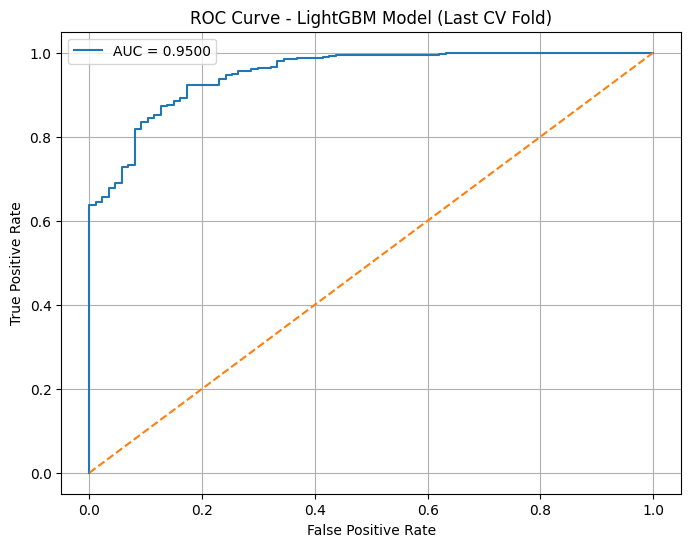

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities from the last fold
pred_prob_last_fold = model_lgbm_cv.predict_proba(X_test_fold)[:, 1]

# ROC points
fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(y_test_fold, pred_prob_last_fold)

# AUC
auc_score_lgbm = roc_auc_score(y_test_fold, pred_prob_last_fold)

print(f"AUC for last LightGBM fold: {auc_score_lgbm:.4f}")

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_lgbm, tpr_lgbm, label=f"AUC = {auc_score_lgbm:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM Model (Last CV Fold)")
plt.legend()
plt.grid(True)

plt.show()

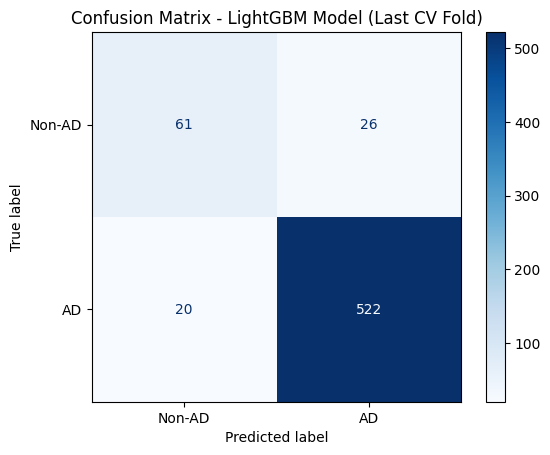

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Predicted classes from the last fold
pred_class_last_fold = model_lgbm_cv.predict(X_test_fold)

cm_lgbm = confusion_matrix(y_test_fold, pred_class_last_fold)

disp_lgbm = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=["Non-AD", "AD"]
)

disp_lgbm.plot(cmap="Blues")
plt.title("Confusion Matrix - LightGBM Model (Last CV Fold)")
plt.show()

In [ ]:
import joblib

joblib.dump(model_lgbm_cv, "alzheimers_lightgbm_cv.pkl")

['alzheimers_lightgbm_cv.pkl']

In [ ]:
import os
print(os.path.exists("alzheimers_lightgbm_cv.pkl"))

True


In [ ]:
from google.colab import files

files.download("alzheimers_lightgbm_cv.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(targets)

['MOMAUTO', 'FLUF', 'MEMUNITS', 'LOGIMEM', 'GDS', 'TRAILB', 'TRAILA', 'WORDDEL', 'WORDIM', 'BOSTON', 'DADDEM', 'ANIMALS', 'MOMDEM', 'BIRTHMO', 'BIRTHYR', 'MARISTAT', 'RACE', 'HISPANIC', 'EDUC', 'PRIMLANG', 'HANDED', 'GENDER', 'VISITAGE']


In [ ]:
targets = ['EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO', 'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS', 'ANIMALS', 'BOSTON', 'TRAILA', 'TRAILB', 'FLUF', 'GDS']

## Retraining LightGBM with the `targets` features using 5-Fold Cross-Validation

I will now retrain the LightGBM model using the `targets` features that were just updated. The 5-fold cross-validation methodology will be applied to ensure robust evaluation of the model's performance with these selected features.

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np

# X_target_model_filled and y_target_model were already prepared in a previous cell
# using the 'targets' features. We will reuse them here.

# Initialize Stratified K-Fold Cross-Validation
skf_lgbm_new_targets = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
aucs_lgbm_new_targets = []
accuracies_lgbm_new_targets = []
f1_scores_lgbm_new_targets = []
precisions_lgbm_new_targets = []
recalls_lgbm_new_targets = []

print("Starting 5-Fold Cross-Validation with LightGBM on updated 'targets' features...")

for fold, (train_index, test_index) in enumerate(skf_lgbm_new_targets.split(X_target_model_filled, y_target_model)):
    print(f"\n--- Fold {fold+1} ---")

    X_train_fold, X_test_fold = X_target_model_filled.iloc[train_index], X_target_model_filled.iloc[test_index]
    y_train_fold, y_test_fold = y_target_model.iloc[train_index], y_target_model.iloc[test_index]

    # Initialize LightGBM model for the fold
    model_lgbm_cv_new_targets = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    )

    # Train model
    model_lgbm_cv_new_targets.fit(X_train_fold, y_train_fold)

    # Predict probabilities and classes
    pred_prob_fold = model_lgbm_cv_new_targets.predict_proba(X_test_fold)[:, 1]
    pred_class_fold = model_lgbm_cv_new_targets.predict(X_test_fold)

    # Calculate metrics
    auc_fold = roc_auc_score(y_test_fold, pred_prob_fold)
    accuracy_fold = accuracy_score(y_test_fold, pred_class_fold)
    f1_fold = f1_score(y_test_fold, pred_class_fold)
    precision_fold = precision_score(y_test_fold, pred_class_fold)
    recall_fold = recall_score(y_test_fold, pred_class_fold)

    # Store metrics
    aucs_lgbm_new_targets.append(auc_fold)
    accuracies_lgbm_new_targets.append(accuracy_fold)
    f1_scores_lgbm_new_targets.append(f1_fold)
    precisions_lgbm_new_targets.append(precision_fold)
    recalls_lgbm_new_targets.append(recall_fold)

    # Print metrics for the current fold
    print(f"AUC: {auc_fold:.4f}")
    print(f"Accuracy: {accuracy_fold:.4f}")
    print(f"F1 Score: {f1_fold:.4f}")
    print(f"Precision: {precision_fold:.4f}")
    print(f"Recall: {recall_fold:.4f}")

print("\n--- Average Metrics Across 5 Folds (LightGBM on new 'targets' features) ---")
print(f"Average AUC: {np.mean(aucs_lgbm_new_targets):.4f} (+/- {np.std(aucs_lgbm_new_targets):.4f})")
print(f"Average Accuracy: {np.mean(accuracies_lgbm_new_targets):.4f} (+/- {np.std(accuracies_lgbm_new_targets):.4f})")
print(f"Average F1 Score: {np.mean(f1_scores_lgbm_new_targets):.4f} (+/- {np.std(f1_scores_lgbm_new_targets):.4f})")
print(f"Average Precision: {np.mean(precisions_lgbm_new_targets):.4f} (+/- {np.std(precisions_lgbm_new_targets):.4f})")
print(f"Average Recall: {np.mean(recalls_lgbm_new_targets):.4f} (+/- {np.std(recalls_lgbm_new_targets):.4f})")

Starting 5-Fold Cross-Validation with LightGBM on updated 'targets' features...

--- Fold 1 ---
[LightGBM] [Info] Number of positive: 2168, number of negative: 351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 878
[LightGBM] [Info] Number of data points in the train set: 2519, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
AUC: 0.9275
Accuracy: 0.9206
F1 Score: 0.9545
Precision: 0.9425
Recall: 0.9669

--- Fold 2 ---
[LightGBM] [Info] Number of positive: 2169, number of negative: 350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000616 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

AUC for last LightGBM fold with new targets: 0.9500


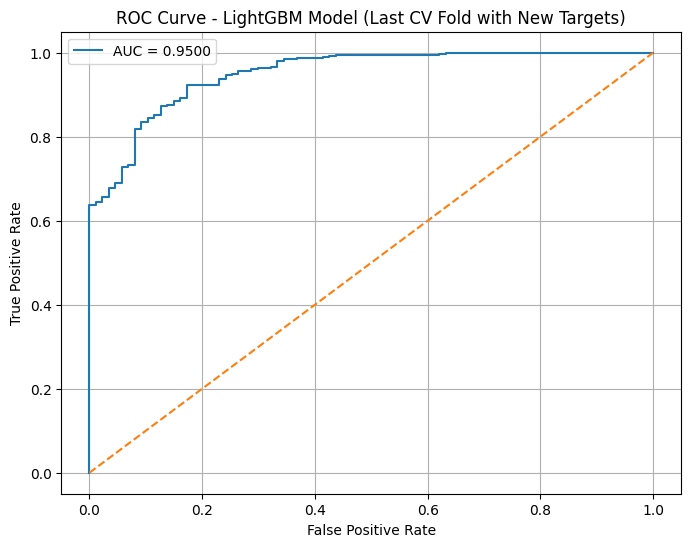

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities from the last fold (model_lgbm_cv and X_test_fold are available from the previous cell)
pred_prob_lgbm_new_targets = model_lgbm_cv_new_targets.predict_proba(X_test_fold)[:, 1]

# ROC points
fpr_lgbm_new_targets, tpr_lgbm_new_targets, thresholds_lgbm_new_targets = roc_curve(y_test_fold, pred_prob_lgbm_new_targets)

# AUC
auc_score_lgbm_new_targets = roc_auc_score(y_test_fold, pred_prob_lgbm_new_targets)

print(f"AUC for last LightGBM fold with new targets: {auc_score_lgbm_new_targets:.4f}")

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_lgbm_new_targets, tpr_lgbm_new_targets, label=f"AUC = {auc_score_lgbm_new_targets:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM Model (Last CV Fold with New Targets)")
plt.legend()
plt.grid(True)

plt.show()

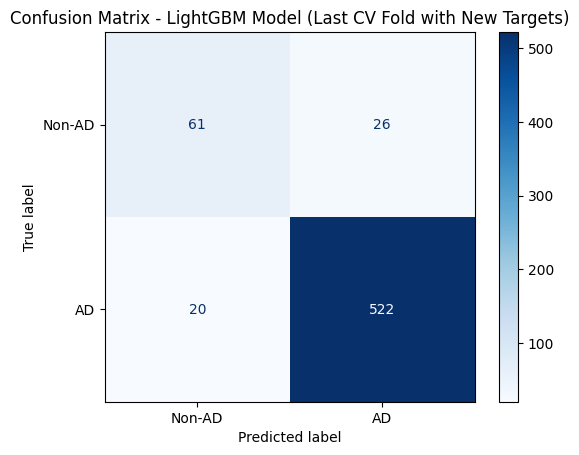

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Predicted classes from the last fold
pred_class_lgbm_new_targets = model_lgbm_cv_new_targets.predict(X_test_fold)

cm_lgbm_new_targets = confusion_matrix(
    y_test_fold,
    pred_class_lgbm_new_targets
)

disp_lgbm_new_targets = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm_new_targets,
    display_labels=["Non-AD", "AD"]
)

disp_lgbm_new_targets.plot(cmap="Blues")
plt.title("Confusion Matrix - LightGBM Model (Last CV Fold with New Targets)")
plt.show()

In [ ]:
print(targets)

['EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO', 'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS', 'ANIMALS', 'BOSTON', 'TRAILA', 'TRAILB', 'FLUF', 'GDS']


In [ ]:
stick=['EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO', 'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS', 'ANIMALS', 'BOSTON', 'TRAILA', 'TRAILB', 'FLUF', 'GDS']


## Training a new LightGBM model using the `stick` features with 5-Fold Cross-Validation

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np

# Prepare X and y using the 'stick' features
X_stick_model = df_filtered[stick].copy()
y_stick_model = df_filtered["ADGROUP"].astype(int).copy()

# Fill NaNs with 0
X_stick_model_filled = X_stick_model.fillna(0)

print(f"Shape of X_stick_model_filled: {X_stick_model_filled.shape}")
print(f"Number of missing values in X_stick_model_filled: {X_stick_model_filled.isnull().sum().sum()}")

# Initialize Stratified K-Fold Cross-Validation
skf_lgbm_stick = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for each fold
aucs_lgbm_stick = []
accuracies_lgbm_stick = []
f1_scores_lgbm_stick = []
precisions_lgbm_stick = []
recalls_lgbm_stick = []

print("\nStarting 5-Fold Cross-Validation with LightGBM on 'stick' features...")

for fold, (train_index, test_index) in enumerate(skf_lgbm_stick.split(X_stick_model_filled, y_stick_model)):
    print(f"\n--- Fold {fold+1} ---")

    X_train_fold, X_test_fold = X_stick_model_filled.iloc[train_index], X_stick_model_filled.iloc[test_index]
    y_train_fold, y_test_fold = y_stick_model.iloc[train_index], y_stick_model.iloc[test_index]

    # Initialize LightGBM model for the fold
    model_lgbm_cv_stick = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    )

    # Train model
    model_lgbm_cv_stick.fit(X_train_fold, y_train_fold)

    # Predict probabilities and classes
    pred_prob_fold = model_lgbm_cv_stick.predict_proba(X_test_fold)[:, 1]
    pred_class_fold = model_lgbm_cv_stick.predict(X_test_fold)

    # Calculate metrics
    auc_fold = roc_auc_score(y_test_fold, pred_prob_fold)
    accuracy_fold = accuracy_score(y_test_fold, pred_class_fold)
    f1_fold = f1_score(y_test_fold, pred_class_fold)
    precision_fold = precision_score(y_test_fold, pred_class_fold)
    recall_fold = recall_score(y_test_fold, pred_class_fold)

    # Store metrics
    aucs_lgbm_stick.append(auc_fold)
    accuracies_lgbm_stick.append(accuracy_fold)
    f1_scores_lgbm_stick.append(f1_fold)
    precisions_lgbm_stick.append(precision_fold)
    recalls_lgbm_stick.append(recall_fold)

    # Print metrics for the current fold
    print(f"AUC: {auc_fold:.4f}")
    print(f"Accuracy: {accuracy_fold:.4f}")
    print(f"F1 Score: {f1_fold:.4f}")
    print(f"Precision: {precision_fold:.4f}")
    print(f"Recall: {recall_fold:.4f}")

print("\n--- Average Metrics Across 5 Folds (LightGBM on 'stick' features) ---")
print(f"Average AUC: {np.mean(aucs_lgbm_stick):.4f} (+/- {np.std(aucs_lgbm_stick):.4f})")
print(f"Average Accuracy: {np.mean(accuracies_lgbm_stick):.4f} (+/- {np.std(accuracies_lgbm_stick):.4f})")
print(f"Average F1 Score: {np.mean(f1_scores_lgbm_stick):.4f} (+/- {np.std(f1_scores_lgbm_stick):.4f})")
print(f"Average Precision: {np.mean(precisions_lgbm_stick):.4f} (+/- {np.std(precisions_lgbm_stick):.4f})")
print(f"Average Recall: {np.mean(recalls_lgbm_stick):.4f} (+/- {np.std(recalls_lgbm_stick):.4f})")


Shape of X_stick_model_filled: (3149, 23)
Number of missing values in X_stick_model_filled: 0

Starting 5-Fold Cross-Validation with LightGBM on 'stick' features...

--- Fold 1 ---
[LightGBM] [Info] Number of positive: 2168, number of negative: 351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 2519, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
AUC: 0.9191
Accuracy: 0.9175
F1 Score: 0.9525
Precision: 0.9456
Recall: 0.9595

--- Fold 2 ---
[LightGBM] [Info] Number of positive: 2169, number of negative: 350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000409 seconds.
Y

AUC for last LightGBM 'stick' features fold: 0.9476


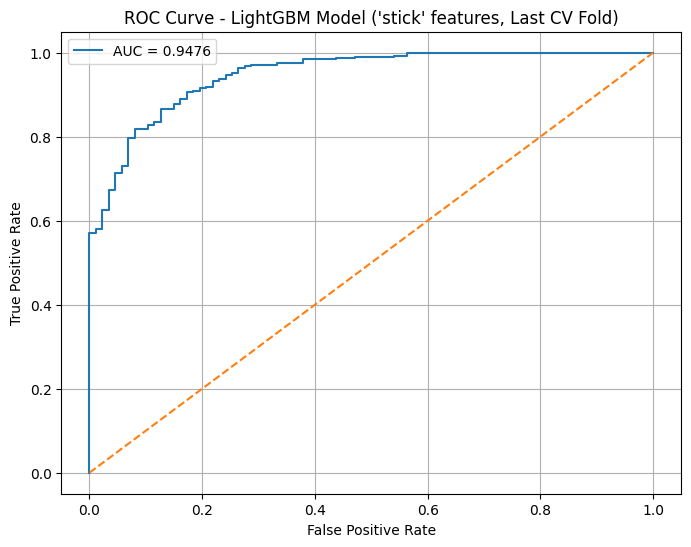

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities from the last fold of the 'stick' model cross-validation
pred_prob_lgbm_stick_last_fold = model_lgbm_cv_stick.predict_proba(X_test_fold)[:, 1]

# ROC points
fpr_lgbm_stick, tpr_lgbm_stick, thresholds_lgbm_stick = roc_curve(y_test_fold, pred_prob_lgbm_stick_last_fold)

# AUC
auc_score_lgbm_stick_last_fold = roc_auc_score(y_test_fold, pred_prob_lgbm_stick_last_fold)

print(f"AUC for last LightGBM 'stick' features fold: {auc_score_lgbm_stick_last_fold:.4f}")

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_lgbm_stick, tpr_lgbm_stick, label=f"AUC = {auc_score_lgbm_stick_last_fold:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM Model ('stick' features, Last CV Fold)")
plt.legend()
plt.grid(True)

plt.show()

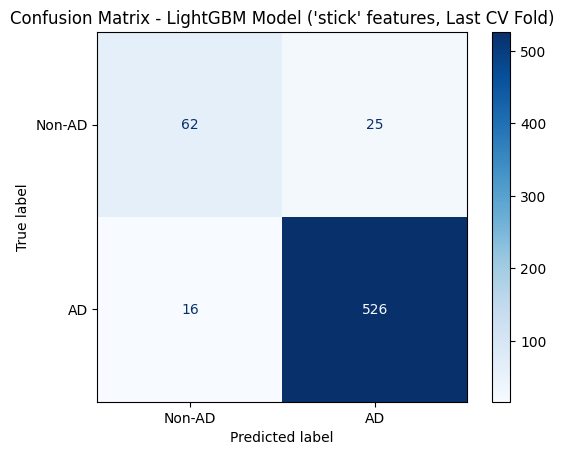

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Predicted classes from the last fold of the 'stick' model cross-validation
pred_class_lgbm_stick_last_fold = model_lgbm_cv_stick.predict(X_test_fold)

cm_lgbm_stick = confusion_matrix(
    y_test_fold,
    pred_class_lgbm_stick_last_fold
)

disp_lgbm_stick = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm_stick,
    display_labels=["Non-AD", "AD"]
)

disp_lgbm_stick.plot(cmap="Blues")
plt.title("Confusion Matrix - LightGBM Model ('stick' features, Last CV Fold)")
plt.show()

In [ ]:
print(stick
      )

['EDUC', 'BIRTHMO', 'BIRTHYR', 'HISPANIC', 'RACE', 'PRIMLANG', 'MARISTAT', 'HANDED', 'GENDER', 'MOMDEM', 'MOMAUTO', 'DADDEM', 'DADAUTO', 'WORDIM', 'WORDDEL', 'LOGIMEM', 'MEMUNITS', 'ANIMALS', 'BOSTON', 'TRAILA', 'TRAILB', 'FLUF', 'GDS']
